### K-Means를 이용한 붓꽃(Iris) 데이터 셋 Clustering

In [ ]:
class sklearn.cluster.KMeans(
    n_clusters=8,
    init='k-means++',
    n_init=10,
    max_iter=300,
    tol=0.0001,
    precompute_distances='auto',
    verbose=0,
    random_state=None,
    copy_x=True,
    n_jobs=1,
    algorithm='auto'
)

In [1]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# 붓꽃 데이터 로드하기
iris = load_iris()
# 보다 편리한 데이터 Handling을 위해 DataFrame으로 변환
iris_df = pd.DataFrame(iris.data, columns=['sepal_length',	'sepal_width',	'petal_length',	'petal_width'])
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [3]:
#붓꽃 데이터 세트를 3개 그룹으로 군집화하는 Kmeans 개체 생성 및 학습/군집화 수행
# 1. 3개의 그룹으로 군집화하는 K-Means 객체 생성
kmeans = KMeans(n_clusters=3, random_state = 42)
# 2. 붓꽃 데이터에 대해 군집화 학습(수행)
kmeans.fit(iris_df)

KMeans(n_clusters=3, random_state=42)

In [4]:
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

In [5]:
kmeans.cluster_centers_

array([[6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

In [10]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,0
146,6.3,2.5,5.0,1.9,2,2
147,6.5,3.0,5.2,2.0,2,0
148,6.2,3.4,5.4,2.3,2,0


In [18]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000,1.146667
std,0.828066,0.435866,1.765298,0.762238,0.819232,0.805907
min,4.300000,2.000000,1.000000,0.100000,0.000000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000,2.000000


In [9]:
# 실제 분류값인 target과 군집화 분류값인 labels_(cluster)를 이용하여 비교 확인
iris_df['target'] = iris.target
iris_df['cluster']= kmeans.labels_

iris_df.groupby(['target', 'cluster']).size()
# print(iris_result)

target  cluster
0       1          50
1       0           3
        2          47
2       0          36
        2          14
dtype: int64

sepal_length  sepal_width  petal_length  petal_width
target cluster                                                      
0      0                  50           50            50           50
1      1                  48           48            48           48
       2                   2            2             2            2
2      1                  14           14            14           14
       2                  36           36            36           36

In [14]:
kmeans.cluster_centers_

array([[6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

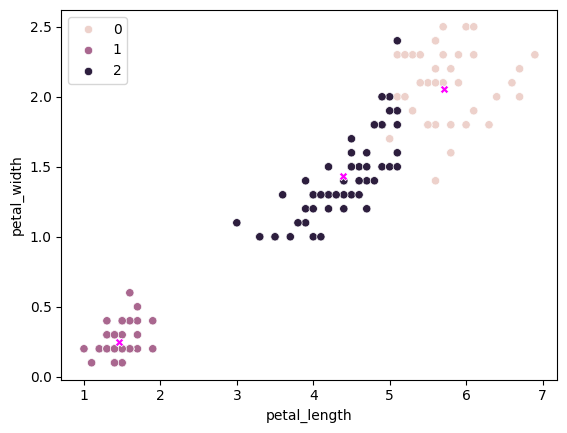

In [17]:
# 군집화 결과 시각화 -> cluster를 기준으로 데이터 시각화, 중심점도 같이
import seaborn as sns 

sns.scatterplot(iris_df,
                x = 'petal_length',
                y = 'petal_width',
                hue='cluster')
sns.scatterplot(x = kmeans.cluster_centers_[:, 2],
                y = kmeans.cluster_centers_[:, 3],
                color = 'magenta',
                marker = 'X')

plt.show()

In [19]:
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris_scaled)

pca_transformed

In [23]:
# PCA 를 이용해 4개의 속성을 2개로 차원 축소한 뒤에 X 좌표, Y 좌표로 개별 데이터를 표현
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 스케일링
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris.data) # iris_df[['sepal_length','sepal_width','petal_length','petal_width']]

# 차원축소
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris_scaled)

# 데이터프레임에 두 속성 추가
iris_df['pca_x'] = pca_transformed[:, 0]
iris_df['pca_y'] = pca_transformed[:, 1]
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.264703,0.480027
1,4.9,3.0,1.4,0.2,0,1,-2.080961,-0.674134
2,4.7,3.2,1.3,0.2,0,1,-2.364229,-0.341908


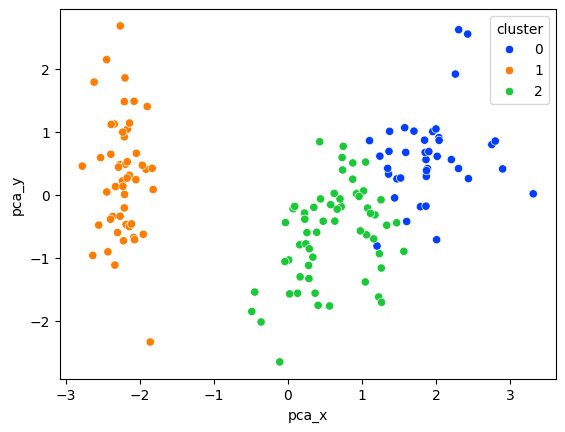

In [27]:
# PCA로 차원 축소된 데이터를 시각화 (산점도)
sns.scatterplot(iris_df,
                x = 'pca_x',
                y = 'pca_y',
                hue='cluster',
                palette='bright')
plt.show()

In [ ]:
#실루엣 분석

In [28]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

# 실루엣 분석 metric 값을 구하기 위한 API 추가
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# iris = load_iris()
# feature_names = ['sepal_length','sepal_width','petal_length','petal_width']
# iris_df = pd.DataFrame(data=iris.data, columns=feature_names)

# kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=42).fit(iris_df)

# iris_df['cluster'] = kmeans.labels_

# iris 의 모든 개별 데이터에 실루엣 계수값을 구함. 
score_samples = silhouette_samples(iris.data, iris_df['cluster'])
print('silhouette_samples( ) return 값의 shape' , score_samples.shape)

# irisDF에 실루엣 계수 컬럼 추가
iris_df['silhouette_coeff'] = score_samples

# 모든 데이터의 평균 실루엣 계수값을 구함. 
average_score = silhouette_score(iris.data, iris_df['cluster'])
print('붓꽃 데이터셋 Silhouette Analysis Score:{0:.3f}'.format(average_score))

iris_df.head(3)

silhouette_samples( ) return 값의 shape (150,)
붓꽃 데이터셋 Silhouette Analysis Score:0.551


,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,-2.264703,0.480027,0.852582
1,4.9,3.0,1.4,0.2,0,1,-2.080961,-0.674134,0.814916
2,4.7,3.2,1.3,0.2,0,1,-2.364229,-0.341908,0.828797


In [29]:
#군집별 평균 실루엣 계수 값으로 확인
iris_df.groupby('cluster')['silhouette_coeff'].mean()

cluster
0    0.436842
1    0.797604
2    0.422323
Name: silhouette_coeff, dtype: float64

In [31]:
iris_df[iris_df['silhouette_coeff']<0]

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y,silhouette_coeff
50,7.0,3.2,4.7,1.4,1,0,1.101781,0.862972,-0.026722


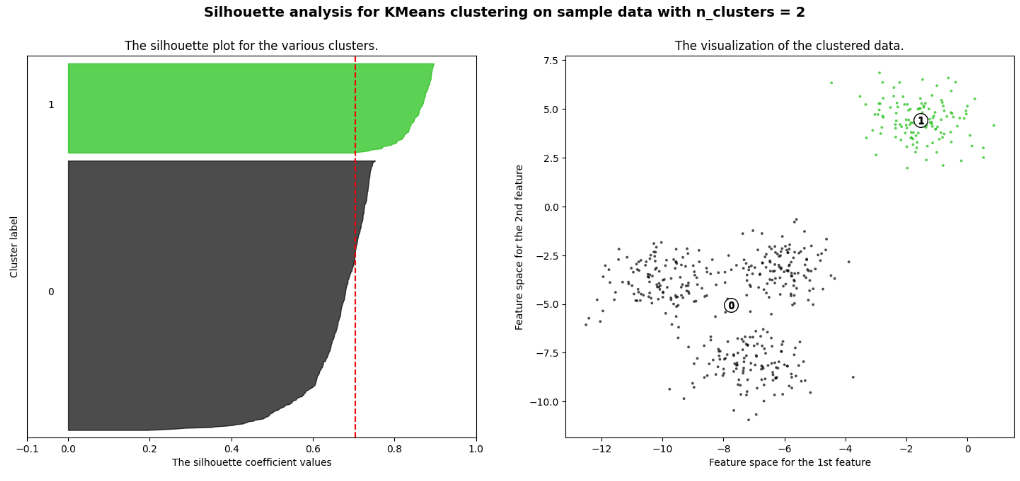

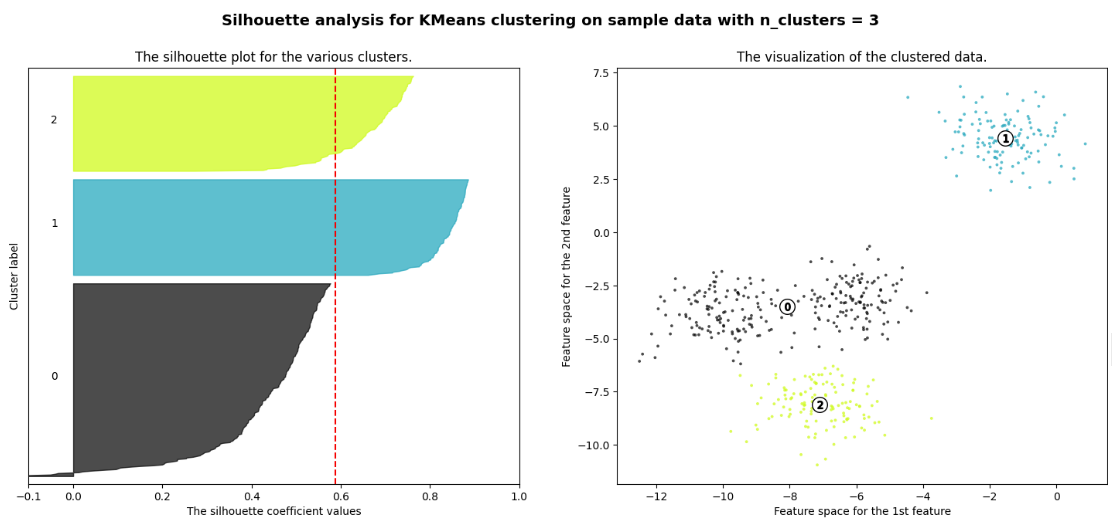

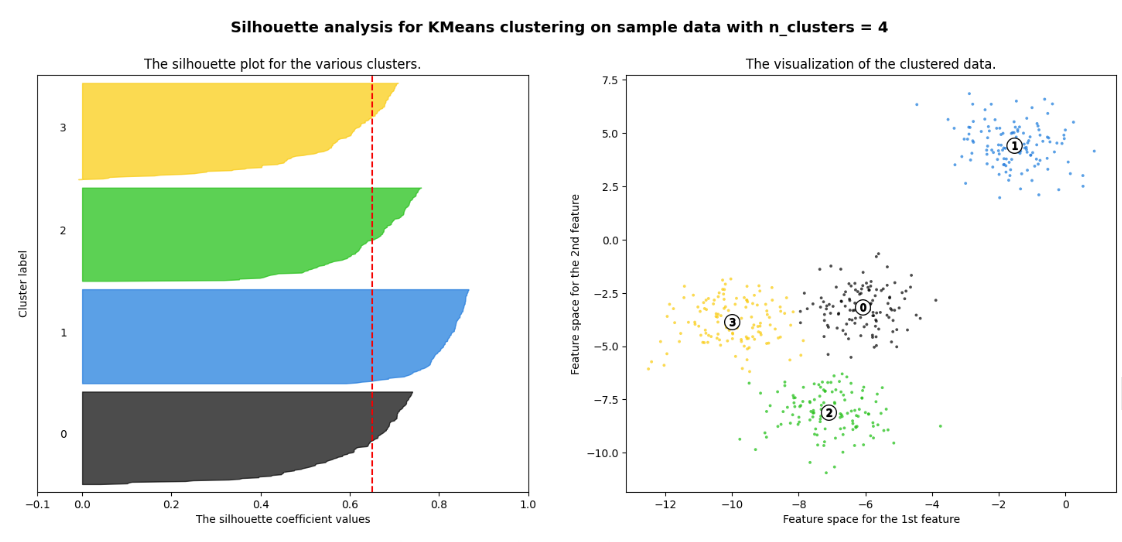

In [32]:
### 여러개의 클러스터링 갯수를 List로 입력 받아 각각의 실루엣 계수를 면적으로 시각화한 함수
def visualize_silhouette(cluster_lists, X_features): 
    
    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math
    
    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)
    
    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
    
    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):
        
        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)
        
        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)
        
        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

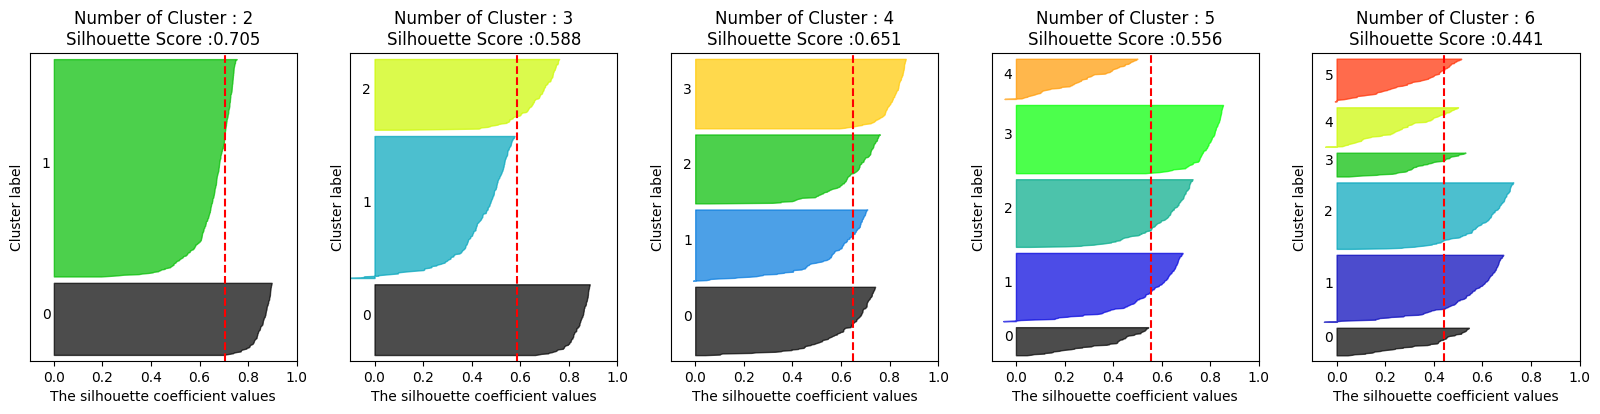

In [33]:
# make_blobs 을 통해 clustering 을 위한 4개의 클러스터 중심의 500개 2차원 데이터 셋 생성  
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1, \
                  center_box=(-10.0, 10.0), shuffle=True, random_state=1)  

# cluster 개수를 2개, 3개, 4개, 5개 일때의 클러스터별 실루엣 계수 평균값을 시각화 
visualize_silhouette([ 2, 3, 4, 5, 6], X)

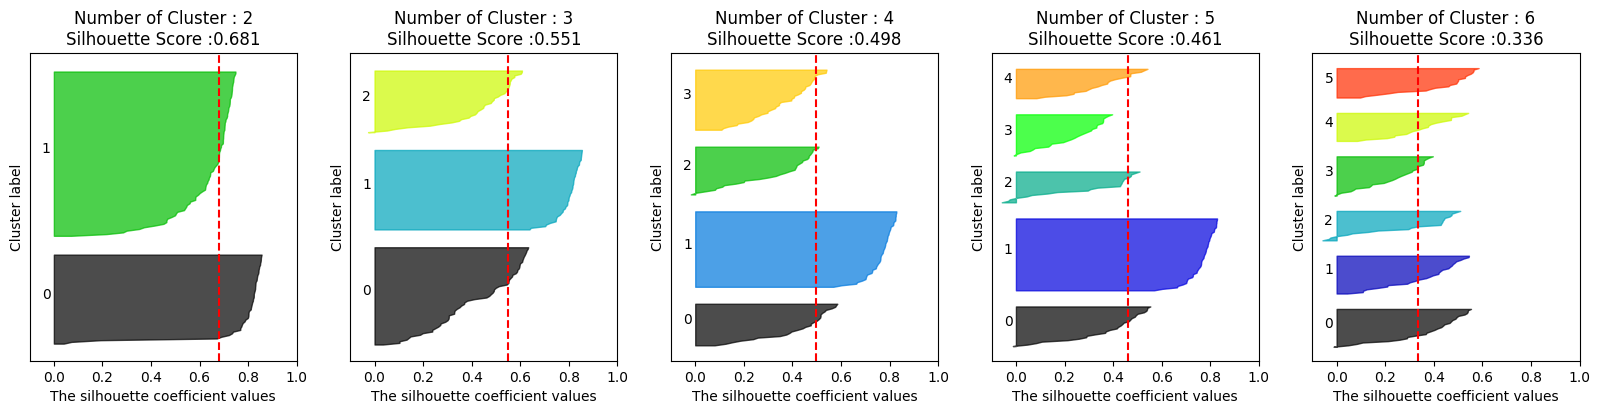

In [34]:
# 붓꽃 데이터를 이용해 K-평균 수행 시 최적의 군집 개수를 알아보기
visualize_silhouette([ 2, 3, 4, 5, 6], iris.data)

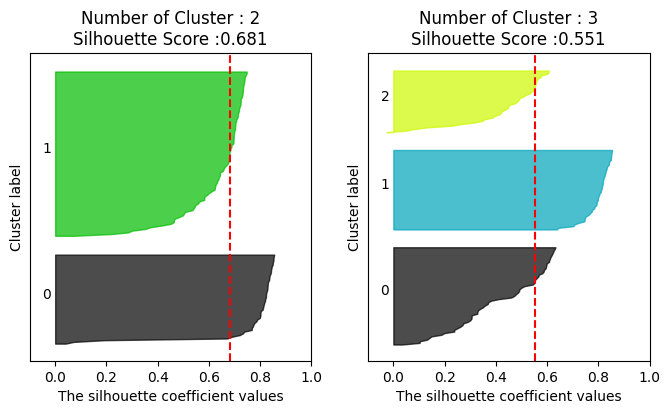

In [35]:
visualize_silhouette([ 2, 3], iris.data)

In [ ]:
# 2개의 군집으로 KMeans를 돌려보시고 이를 시각화

kmeans = KMeans(n_clusters=2, random_state = 42)
kmeans.fit(iris_scaled)

In [ ]:
붓꽃 군집화 결과 정리

#### elbow 방법

In [36]:
inertia = []
for n in range(1, 10):
    km = KMeans(n_clusters=n, random_state=42) # random_state 고정
    km.fit(iris.data)
    print(km.inertia_)
    inertia.append(km.inertia_)

681.3706
152.34795176035792
78.8556658259773
57.350880212954756
46.472230158730156
39.066035353535355
34.30581529581529
30.476222943722945
29.906246659137963


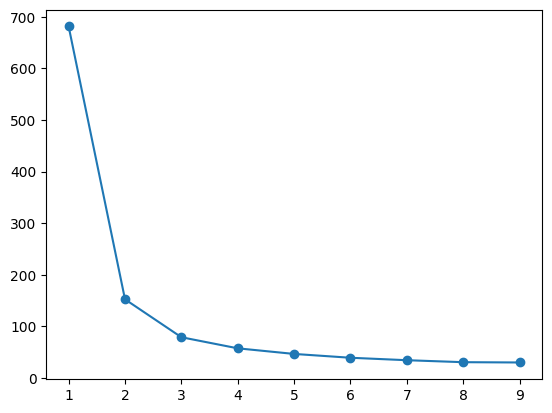

In [38]:
# 그래프로 그리기 
plt.plot(range(1, 10), inertia, marker = 'o')
plt.show()